# Pipeline de nettoyage des données

Ce notebook prend le dataset brut de radiographies thoraciques et produit une version propre,
prête pour passer à la partie data augmentation , sauvegardée dans `C:\Users\Pc\Downloads\xray_pneumonia\datasets\processedData`.

---

## Ce que nous corrigeons et pourquoi

| Problème (détecté lors de l'exploration) | Correction |
|-----------------------------------------|------------|
|Le dossier `val/` ne contient que 16 images — trop peu pour évaluer le modèle pendant l'entraînement | Fusionner les 3 splits originaux en un seul pool, puis refaire un split 70/15/15 stratifié par classe |
| 283 images sont en RGB, 5573 en Grayscale — canaux incohérents qui feraient planter l'entraînement | Convertir toutes les images Grayscale |
| Tailles allant de 384×127 à 2916×2583 — les modèles exigent une taille d'entrée fixe | Redimensionner à 224×224 en ajoutant  du padding et en utilisant le fonction resize pour préserver le rapport d'aspect |
| Les distributions d'intensité des pixels varient fortement entre les images | Appliquer CLAHE (normalisation adaptative du contraste) par image |

---

## Structure de sortie

```
datasets/processedData/
├── train/
│   ├── NORMAL/
│   └── PNEUMONIA/
├── val/
│   ├── NORMAL/
│   └── PNEUMONIA/
└── test/
    ├── NORMAL/
    └── PNEUMONIA/
```


In [2]:
%pip install matplotlib scikit-learn

import os
import shutil
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt 
from PIL import Image, ImageOps
from sklearn.model_selection import train_test_split



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl (8.0 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ----- ---------------------------------- 4.7/36.5 MB 25.9 MB/s eta 0:00:02
   ------------ --------------------------- 11.5/36.5 MB 30.1 MB/s eta 0:00:01
   --------------------- ------------------ 19.7/36.5 MB 32.7 MB/s eta 0:00:01
   ------------------------------ --------- 28.3/36.5 MB 35.2 MB/s eta 0:00:01
   ---------------------------------------  36.4/36.5 MB 36.7 MB/s eta 0:00:01
   ---------------------------------------- 36.5/36.5 MB 33.2 MB/s eta 0:00:00
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.


## Chemins et configuration

In [ ]:
ORIGINAL_DATA = r"C:\Users\Pc\Downloads\xray_pneumonia\datasets\rawData\chest_Xray\chest_Xray"
OUTPUT_DATA   = r"C:\Users\Pc\Downloads\xray_pneumonia\datasets\processedData"

SPLITS  = ["train", "test", "val"]
CLASSES = ["NORMAL", "PNEUMONIA"]

TARGET_SIZE = (224, 224)
SEED = 42
random.seed(SEED)


---
## Étape 1 — Fusionner tous les splits originaux en un seul pool

Le dataset original comporte trois dossiers : `train/`, `val/`, `test/`.
Le dossier val ne contient que 16 images (8 par classe) — trop peu pour fournir
des métriques d'évaluation significatives pendant l'entraînement.

Nous rassemblons tous les chemins d'images des trois dossiers dans une seule liste par classe,
puis nous refaisons le split à partir de zéro.


In [22]:
all_images = {cls: [] for cls in CLASSES}

for split in SPLITS:
    for cls in CLASSES:
        folder = os.path.join(ORIGINAL_DATA, split, cls)
        for filename in os.listdir(folder):
            if filename.lower().endswith((".jpeg", ".jpg", ".png")):
                all_images[cls].append(os.path.join(folder, filename))

for cls in CLASSES:
    print(f"{cls}: {len(all_images[cls])} images")
print(f"\nTotal: {sum(len(v) for v in all_images.values())} images")


NORMAL: 1583 images
PNEUMONIA: 4273 images

Total: 5856 images


---
## Étape 2 — Répartition stratifiée : 70 % train / 15 % val / 15 % test

Nous séparons chaque classe indépendamment afin de conserver le même ratio de classes
(normal/pneumonie) dans les trois jeux. C’est ce qu’on appelle une **répartition stratifiée** —
elle évite qu’un ensemble ait un ratio normal/pneumonie très différent des autres.


In [23]:
def stratified_split(paths, train_ratio=0.70, val_ratio=0.15):
    paths = paths.copy()
    random.shuffle(paths)
    n = len(paths)
    train_end = int(n * train_ratio)
    val_end   = train_end + int(n * val_ratio)
    return {
        "train": paths[:train_end],
        "val":   paths[train_end:val_end],
        "test":  paths[val_end:]
    }

splits = {cls: stratified_split(all_images[cls]) for cls in CLASSES}

print(f"{'Split':<10} {'NORMAL':>10} {'PNEUMONIA':>12} {'Total':>8}")
print("-" * 44)
for split in ["train", "val", "test"]:
    n = len(splits["NORMAL"][split])
    p = len(splits["PNEUMONIA"][split])
    print(f"{split:<10} {n:>10} {p:>12} {n+p:>8}")


Split          NORMAL    PNEUMONIA    Total
--------------------------------------------
train            1108         2991     4099
val               237          640      877
test              238          642      880


---
## Étape 3 — Définir la fonction de nettoyage

Chaque image passe par trois transformations dans l’ordre :

1. **Grayscale** — Les radiographies ne contiennent pas d’information couleur. La conversion
   en Grayscale (mode `L`) élimine les 283 images RGB qui provoqueraient des
   incohérences de canaux lors de l'entraînement.

2. **Redimensionnement avec padding** — `thumbnail()` réduit l’image pour qu’elle tienne
   dans 224×224 sans déformer le ratio. `pad()` complète ensuite les zones manquantes
   avec du noir pour obtenir exactement 224×224. Cela évite de déformer la forme des poumons.

3. **CLAHE** (Égalisation adaptative de l’histogramme à contraste limité) — Standardise le
   contraste local en découpant l’image en petites tuiles et en égalisant chaque tuile
   indépendamment. Cela gère les variations de luminosité observées lors de l’exploration
   sans amplifier excessivement le bruit dans les zones uniformes. Meilleur que l’égalisation
   globale pour les images médicales.


In [24]:
def apply_clahe(pil_img, clip_limit=2.0, tile_grid=(8, 8)):
    arr   = np.array(pil_img, dtype=np.uint8)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    arr   = clahe.apply(arr)
    return Image.fromarray(arr)


def clean_image(img_path, target_size=TARGET_SIZE):
    img = Image.open(img_path)
    img = img.convert("L")                          
    img.thumbnail(target_size, Image.LANCZOS)       
    img = ImageOps.pad(img, target_size, color=0)  
    img = apply_clahe(img)                          
    return img


---
## Étape 4 — Vérification visuelle : avant/après pour une image de chaque classe

Avant de traiter l’ensemble du dataset, nous vérifions visuellement la pipeline.
Nous prenons une image NORMAL et une image PNEUMONIA et affichons l’originale
à côté du résultat nettoyé pour confirmer que les trois transformations fonctionnent.


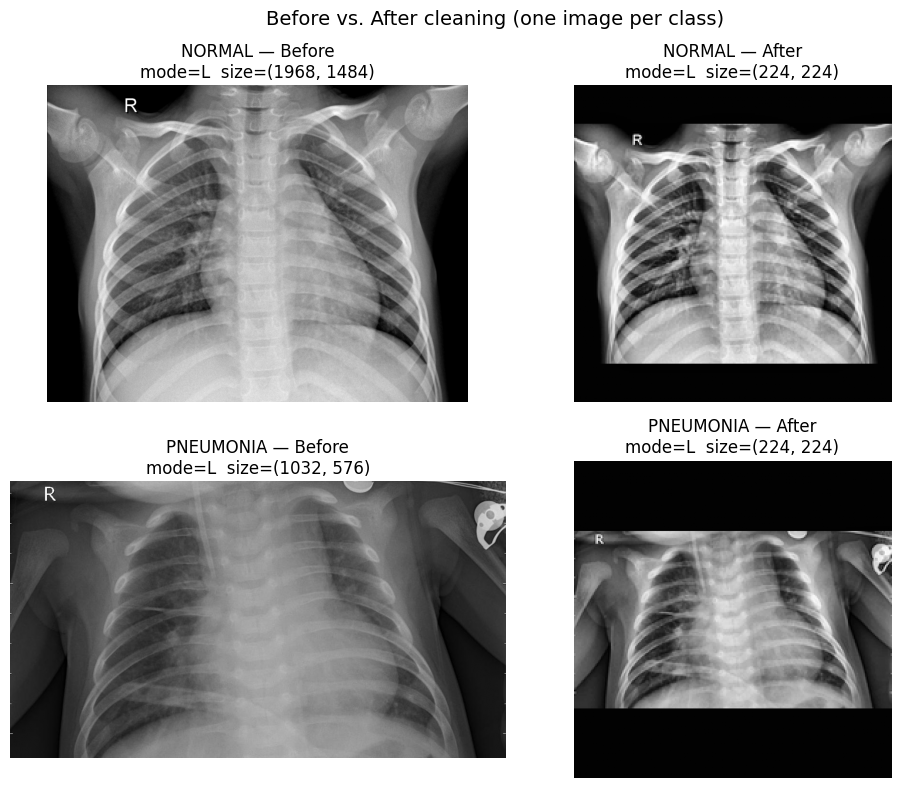

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Before vs. After cleaning (one image per class)", fontsize=14)

for row, cls in enumerate(CLASSES):
    sample_path = splits[cls]["train"][0]
    img_before  = Image.open(sample_path)
    img_after   = clean_image(sample_path)

    axes[row, 0].imshow(img_before, cmap="gray")
    axes[row, 0].set_title(f"{cls} — Before\nmode={img_before.mode}  size={img_before.size}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(img_after, cmap="gray")
    axes[row, 1].set_title(f"{cls} — After\nmode={img_after.mode}  size={img_after.size}")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()


---
## Étape 5 — Vérification visuelle : histogrammes d’intensité des pixels

L’exploration a montré que les distributions de luminosité varient fortement entre les images,
en particulier pour la pneumonie. Ici nous confirmons que CLAHE rend les distributions plus
comparables en traçant des histogrammes avant et après pour un échantillon de chaque classe.


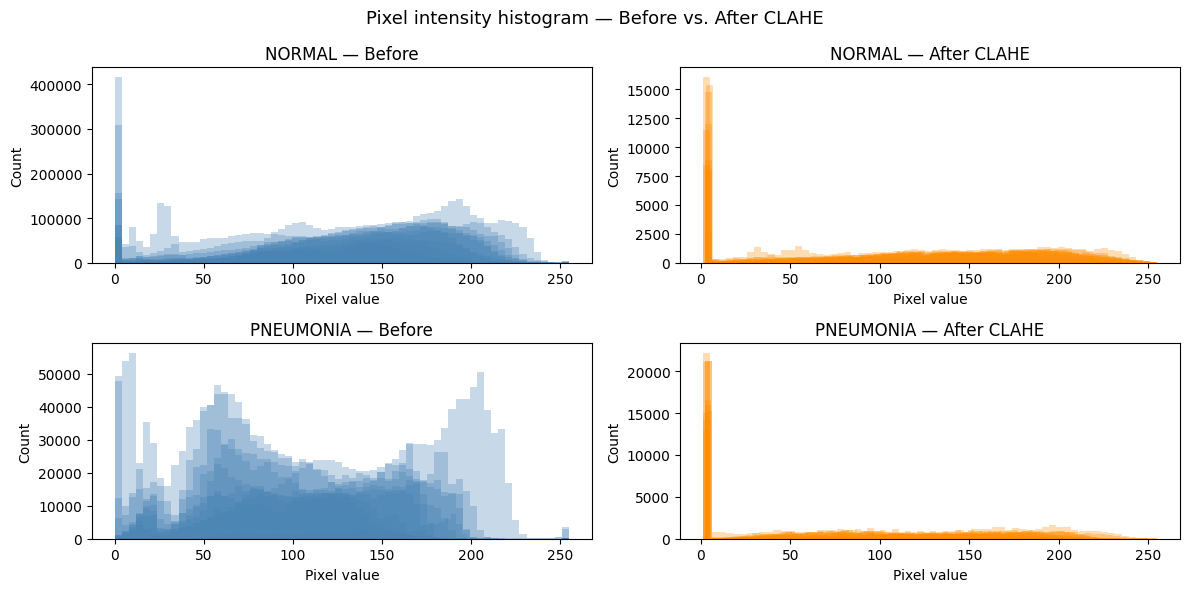

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
fig.suptitle("Pixel intensity histogram — Before vs. After CLAHE", fontsize=13)

for row, cls in enumerate(CLASSES):
    sample_paths = splits[cls]["train"][:10]

    for path in sample_paths:
        raw = Image.open(path).convert("L")
        axes[row, 0].hist(np.array(raw).ravel(), bins=64, alpha=0.3, color="steelblue")

        cleaned = clean_image(path)
        axes[row, 1].hist(np.array(cleaned).ravel(), bins=64, alpha=0.3, color="darkorange")

    axes[row, 0].set_title(f"{cls} — Before")
    axes[row, 1].set_title(f"{cls} — After CLAHE")
    for ax in axes[row]:
        ax.set_xlabel("Pixel value")
        ax.set_ylabel("Count")

plt.tight_layout()
plt.show()


---
## Étape 6 — Traiter et sauvegarder toutes les images

Nous exécutons maintenant la pipeline complète sur chaque image et sauvegardons les
résultats dans `processedData/`. D’abord, nous supprimons toute sortie précédente et
recréons l’arborescence de dossiers, puis nous traitons chaque image et la sauvegardons
dans le dossier correspondant selon le split et la classe.


In [27]:
if os.path.exists(OUTPUT_DATA):
    shutil.rmtree(OUTPUT_DATA)

for split in ["train", "val", "test"]:
    for cls in CLASSES:
        os.makedirs(os.path.join(OUTPUT_DATA, split, cls), exist_ok=True)

print("Output folders created.")


Output folders created.


In [28]:
total_saved = 0
errors      = []

for cls in CLASSES:
    for split in ["train", "val", "test"]:
        out_folder = os.path.join(OUTPUT_DATA, split, cls)

        for src_path in splits[cls][split]:
            filename = os.path.basename(src_path)
            dst_path = os.path.join(out_folder, filename)
            try:
                img = clean_image(src_path)
                img.save(dst_path)
                total_saved += 1
            except Exception as e:
                errors.append((src_path, str(e)))

print(f"Saved: {total_saved} images")
if errors:
    print(f"Errors: {len(errors)}")
    for path, err in errors:
        print(f"  {path}: {err}")
else:
    print("No errors.")


Saved: 5856 images
No errors.


---
## Étape 7 — Vérifier la sortie

Trois vérifications :
1. Le nombre d’images par split et par classe correspond au découpage prévu
2. Chaque image sauvegardée mesure exactement 224×224
3. Chaque image sauvegardée est en niveaux de gris (mode L)


In [29]:
print(f"{'Split':<10} {'NORMAL':>10} {'PNEUMONIA':>12} {'Total':>8}")
print("-" * 44)

for split in ["train", "val", "test"]:
    counts = {}
    for cls in CLASSES:
        folder = os.path.join(OUTPUT_DATA, split, cls)
        counts[cls] = len([f for f in os.listdir(folder)
                           if f.lower().endswith((".jpeg", ".jpg", ".png"))])
    print(f"{split:<10} {counts['NORMAL']:>10} {counts['PNEUMONIA']:>12} {sum(counts.values()):>8}")


Split          NORMAL    PNEUMONIA    Total
--------------------------------------------
train            1108         2991     4099
val               237          640      877
test              238          642      880


In [30]:
train_normal = os.path.join(OUTPUT_DATA, "train", "NORMAL")
sample_files = os.listdir(train_normal)[:50]

sizes = set()
modes = set()

for filename in sample_files:
    img = Image.open(os.path.join(train_normal, filename))
    sizes.add(img.size)
    modes.add(img.mode)

print(f"Unique sizes: {sizes}")
print(f"Unique modes: {modes}")

assert sizes == {(224, 224)}, f"Unexpected sizes: {sizes}"
assert modes == {"L"},        f"Unexpected modes: {modes}"
print("\nAll checks passed.")


Unique sizes: {(224, 224)}
Unique modes: {'L'}

All checks passed.


---
## Résumé du nettoyage

| Étape | Action | Résultat |
|------|--------|----------|
| Fusion | Combinaison train + val + test | 5856 images au total |
| Répartition stratifiée | 70 / 15 / 15 par classe | Ratios équilibrés dans les 3 ensembles |
| Niveaux de gris | Conversion de toutes les images en mode L | Aucune incohérence de canaux |
| Redimensionnement + padding | Thumbnail + remplissage noir à 224×224 | Toutes les images à 224×224 exact, sans distorsion |
| CLAHE | Normalisation adaptative du contraste | Distributions d’intensité standardisées |

`processedData/` est prêt pour la deuxieme partie du preprocessing.
